In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import math
import statsmodels.api as sm
np.random.seed(0)

In [2]:
test = pd.read_csv('D:/mythings/Dataset/HousePrice/Housing Prices Competition for Kaggle Learn Users/test.csv')
train = pd.read_csv('D:/mythings/Dataset/HousePrice/Housing Prices Competition for Kaggle Learn Users/train.csv')

In [3]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
for col in train.columns:
    percent_missing = np.mean(train[col].isnull())
    if percent_missing != 0:
        print(f'{col} - {round(percent_missing*100)}%')

LotFrontage - 18%
Alley - 94%
MasVnrType - 60%
MasVnrArea - 1%
BsmtQual - 3%
BsmtCond - 3%
BsmtExposure - 3%
BsmtFinType1 - 3%
BsmtFinType2 - 3%
Electrical - 0%
FireplaceQu - 47%
GarageType - 6%
GarageYrBlt - 6%
GarageFinish - 6%
GarageQual - 6%
GarageCond - 6%
PoolQC - 100%
Fence - 81%
MiscFeature - 96%


In [6]:
train = train.drop(columns =['Alley','MasVnrType','FireplaceQu','PoolQC','Fence','MiscFeature'])
test = test.drop(columns =['Alley','MasVnrType','FireplaceQu','PoolQC','Fence','MiscFeature'])

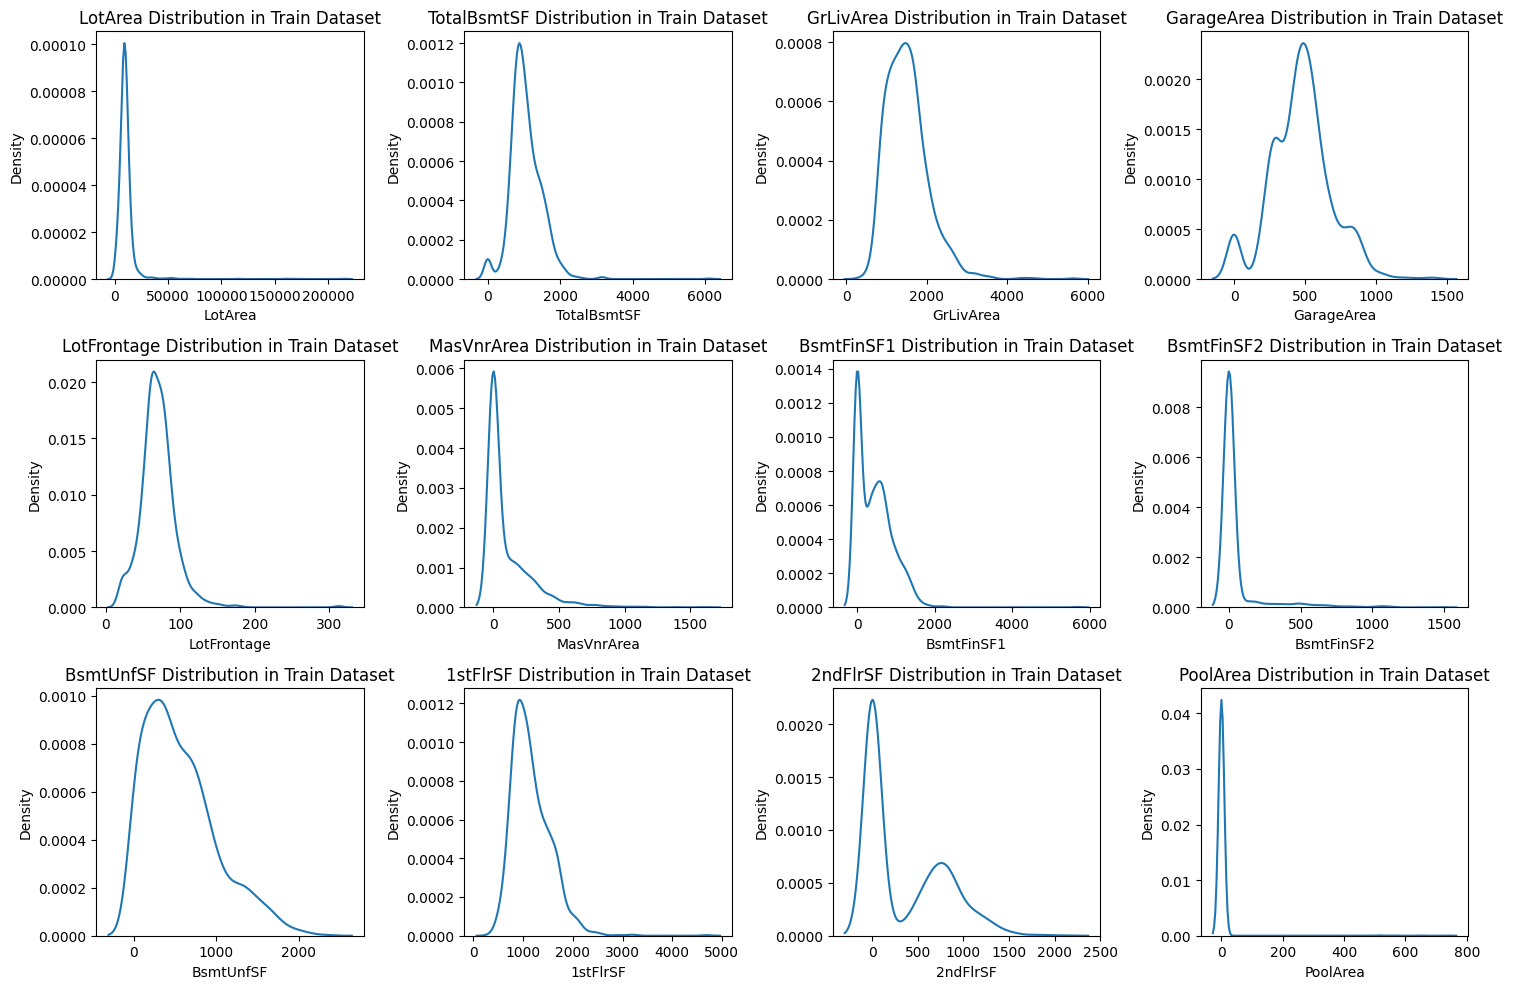

In [7]:
Area = ['LotArea','TotalBsmtSF','GrLivArea','GarageArea','LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
            'BsmtUnfSF', '1stFlrSF', '2ndFlrSF','PoolArea']
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize=(15,10))
index = 0
for row in range(len(axes)):
    for col in range(len(axes[row])):
        sns.kdeplot(train, x = Area[index], ax = axes[row][col])
        axes[row][col].set_title(f'{Area[index]} Distribution in Train Dataset')
        index +=1
        if index == len(Area):
            break
plt.tight_layout()

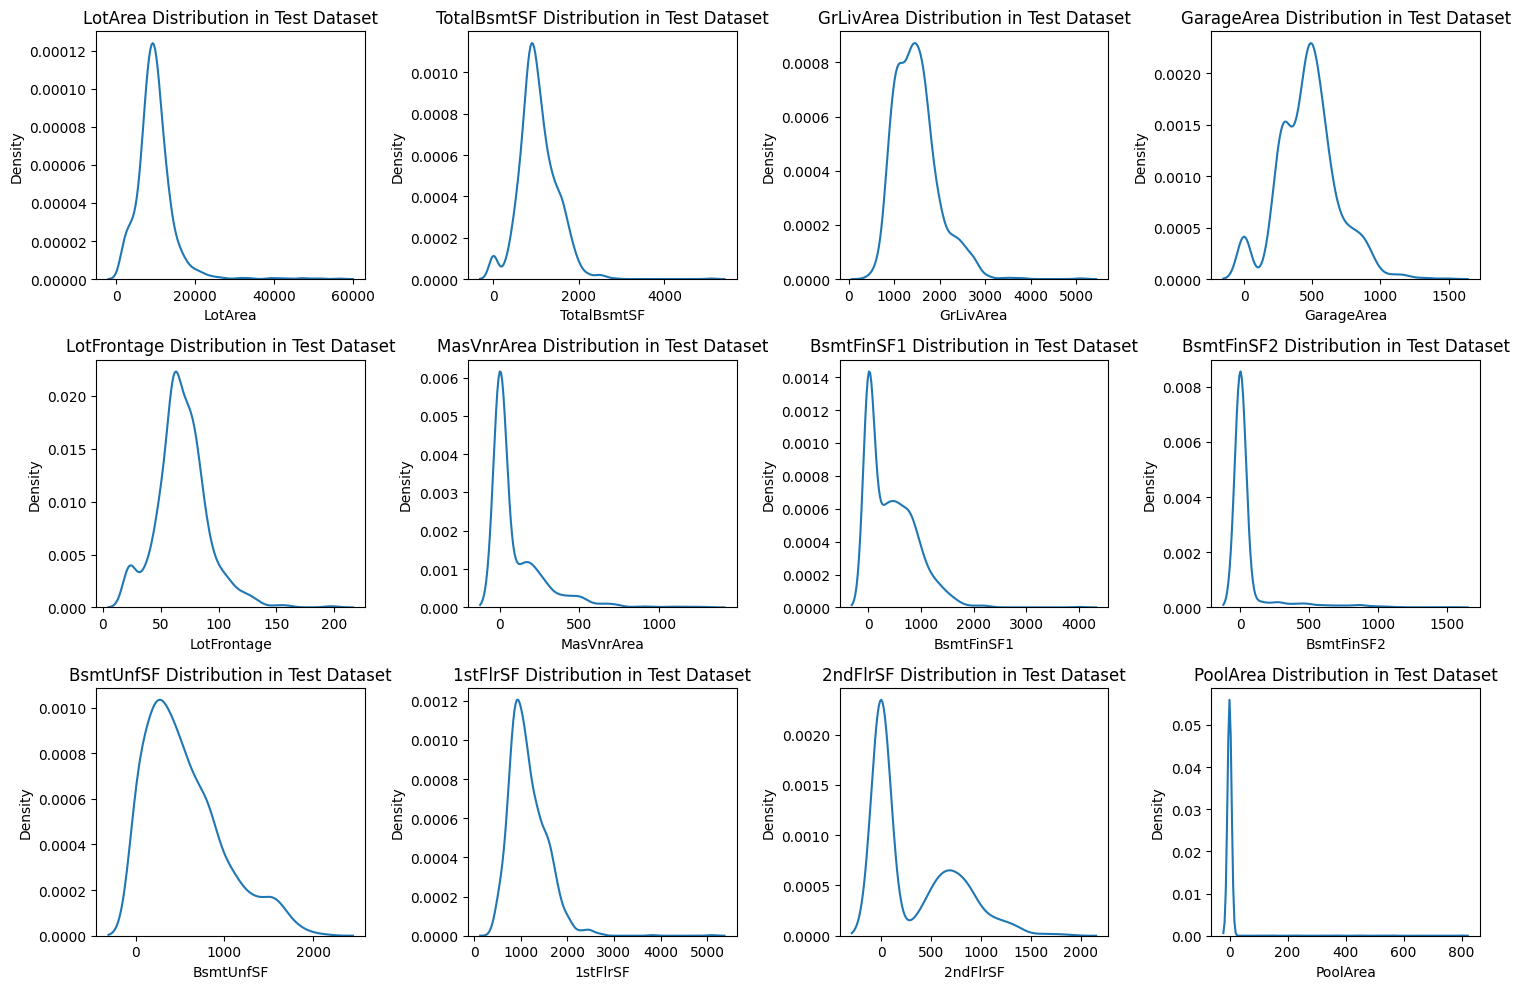

In [8]:
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15,10))
index = 0
for row in range(len(axes)):
    for col in range(len(axes[row])):
        sns.kdeplot(test, x = Area[index], ax = axes[row][col])
        axes[row][col].set_title('{} Distribution in Test Dataset'.format(Area[index]))
        index +=1
        if index == len(Area):
            break
plt.tight_layout()
# it seems like there are no differences between test and train datasets

### Exploring Data Analysis

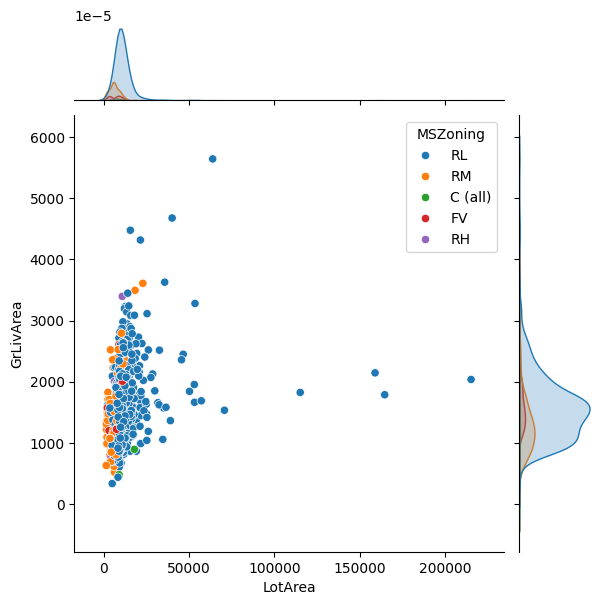

In [9]:
sns.jointplot(train, x = 'LotArea', y = 'GrLivArea', hue ='MSZoning')
# GrLivArea might be greater if LotArea is small, which means ground living area is ultilised 
# and built into building or many stories of a house
# Outliers might lie in LotArea with MSZoning RL

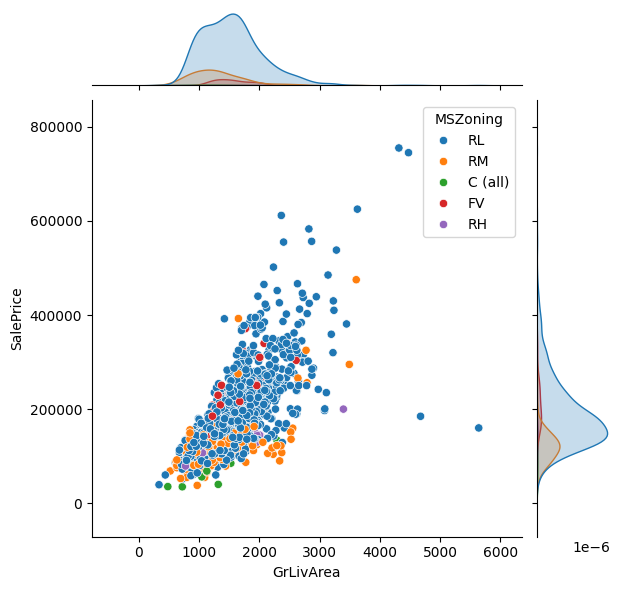

In [10]:
sns.jointplot(train, x = 'GrLivArea', y ='SalePrice', hue = 'MSZoning')

<Axes: xlabel='GrLivArea', ylabel='Count'>

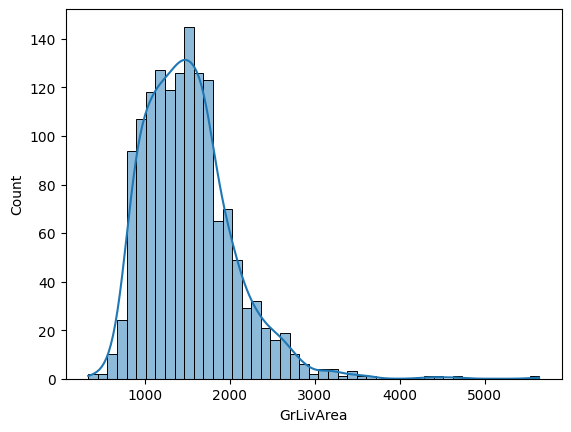

In [11]:
sns.histplot(train, x ='GrLivArea', kde = True)
# The Distribution is skewed to right, so there is a need to transform the shape of distribution
# to Gaussian distribution

<Axes: xlabel='LotArea', ylabel='Count'>

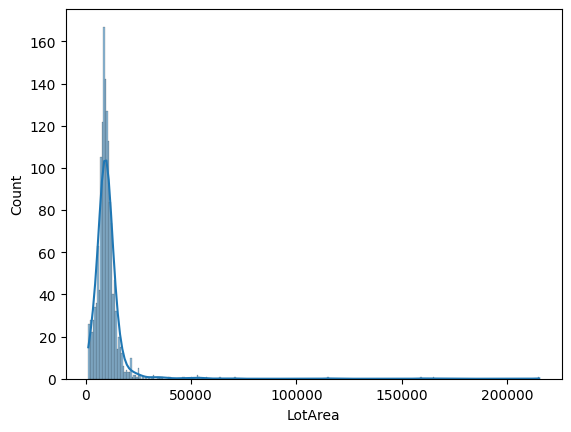

In [12]:
sns.histplot(train, x = 'LotArea', kde = True)
# The Distribution is skewed to right, so there is a need to transform the shape of distribution
# to Gaussian distribution

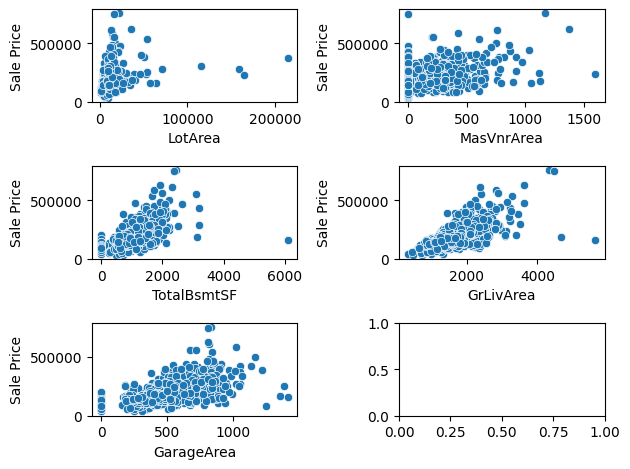

In [13]:
fig, ax = plt.subplots(nrows = 3, ncols = 2)
for index, col in enumerate(['LotArea','MasVnrArea','TotalBsmtSF','GrLivArea','GarageArea']):
    r = index // 2
    c = index % 2
    sns.scatterplot(data = train, x = col, y = 'SalePrice', ax = ax[r][c])
    ax[r][c].set_ylabel('Sale Price')
    plt.tight_layout()

Text(0, 0.5, 'House Sale Price')

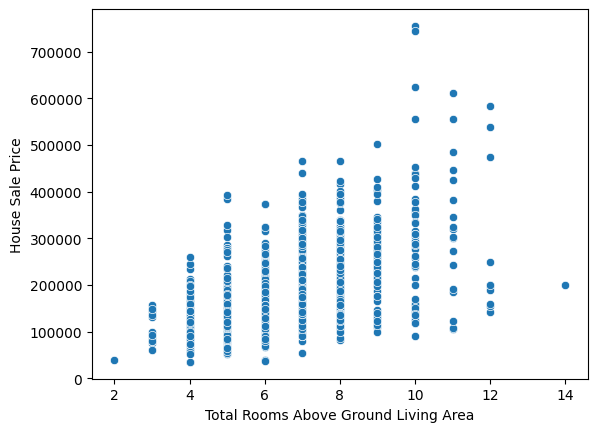

In [14]:
sns.scatterplot(train, x = 'TotRmsAbvGrd', y = 'SalePrice')
plt.xlabel('Total Rooms Above Ground Living Area')
plt.ylabel('House Sale Price')

In [15]:
def detect_outliers_iqr(df, feature):
    df[feature] = sorted(df[feature])
    q1 = np.percentile(df[feature], 25)
    q3 = np.percentile(df[feature], 75)
    IQR = q3 - q1
    lower_bound =q1 - (1.5 *IQR)
    upper_bound = q3 + (1.5*IQR)
    return lower_bound, upper_bound

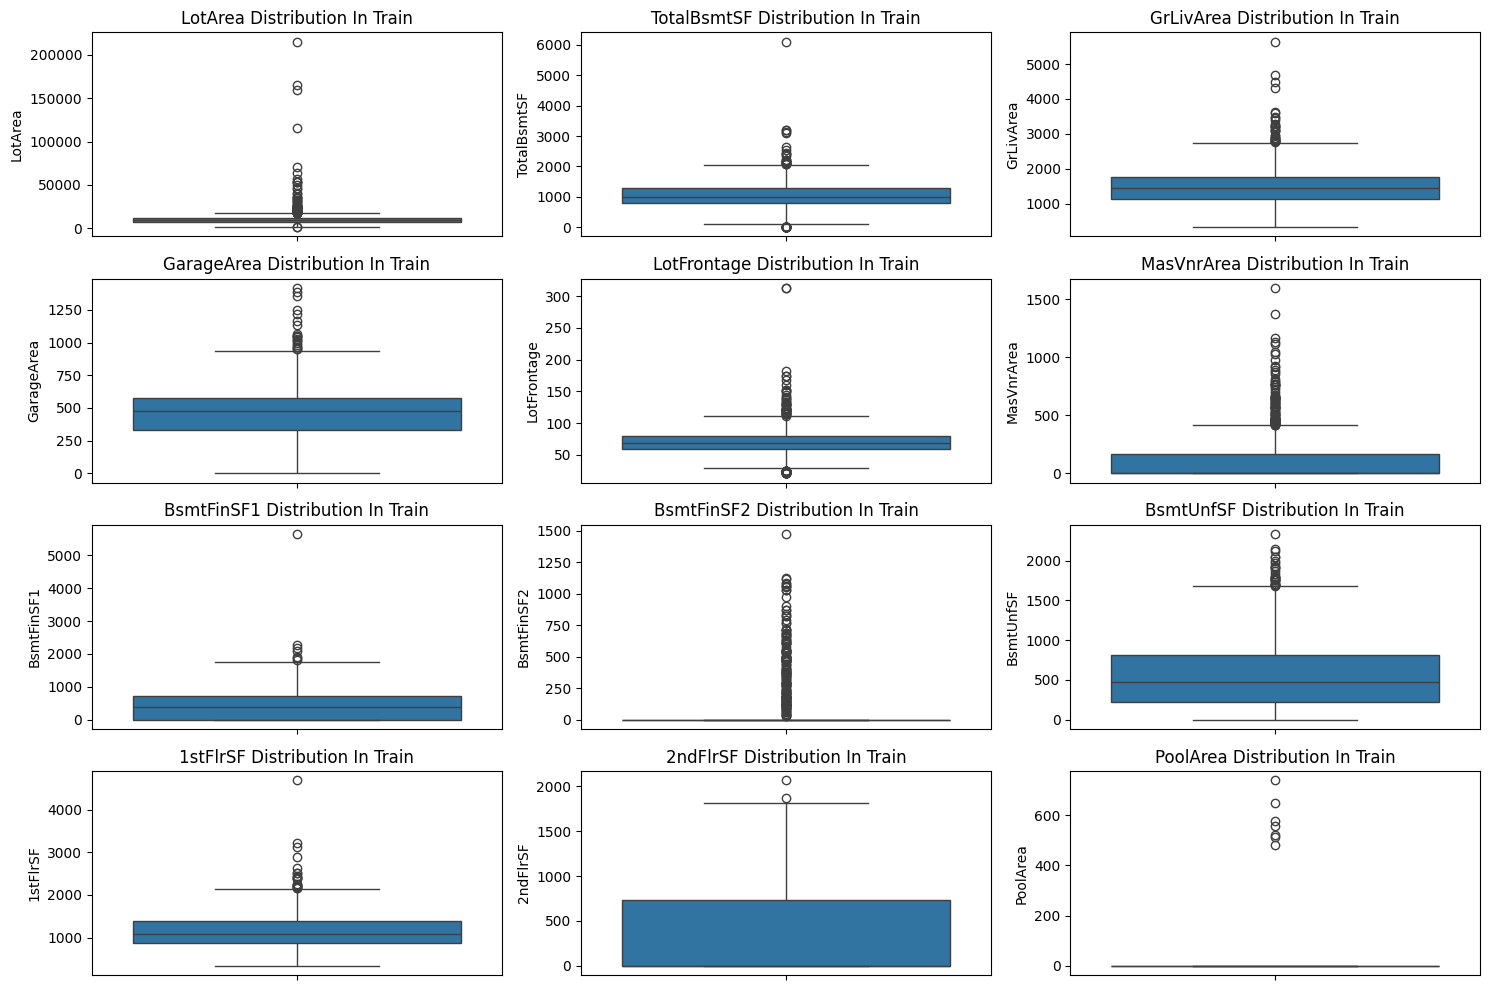

In [16]:
Area = ['LotArea','TotalBsmtSF','GrLivArea','GarageArea','LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
            'BsmtUnfSF', '1stFlrSF', '2ndFlrSF','PoolArea']
fig, ax = plt.subplots(nrows = 4, ncols = 3, figsize =(15,10))
index = 0
for row in range(len(ax)):
    for col in range(len(ax[row])):
        sns.boxplot(train, y = Area[index], ax = ax[row][col])
        ax[row][col].set_title(f'{Area[index]} Distribution In Train')
        index +=1
        plt.tight_layout()
        if index == len(Area):
            break

Text(0, 0.5, 'Sum of Sale Price (Thousand/$)')

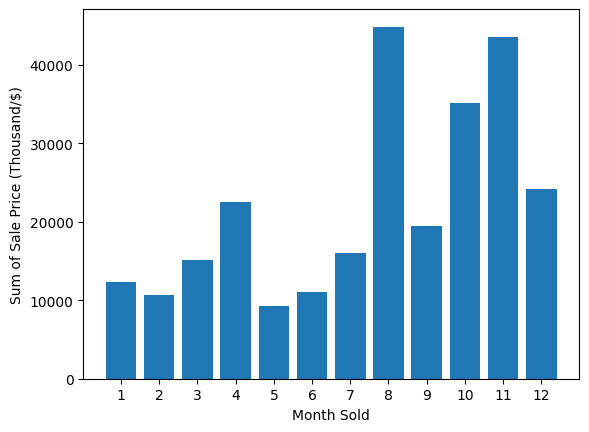

In [17]:
month_sold = train['MoSold'].unique()
plt.bar(month_sold, train.groupby('MoSold')['SalePrice'].sum()/1000)
plt.xticks(month_sold)
plt.xlabel('Month Sold')
plt.ylabel('Sum of Sale Price (Thousand/$)')

Text(0, 0.5, 'Sum of Sale Price (Thousand/$)')

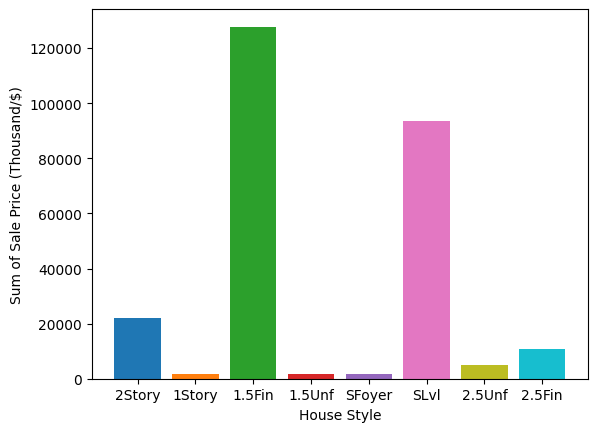

In [18]:
house_style = train['HouseStyle'].unique()
bar_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red','tab:purple','tab:pink','tab:olive', 'tab:cyan']
plt.bar(house_style, train.groupby(['HouseStyle'])['SalePrice'].sum()/1000, color = bar_colors)
plt.xticks(house_style)
plt.xlabel('House Style')
plt.ylabel('Sum of Sale Price (Thousand/$)')

Text(0, 0.5, 'Sum of Sale Price (Thousand/$)')

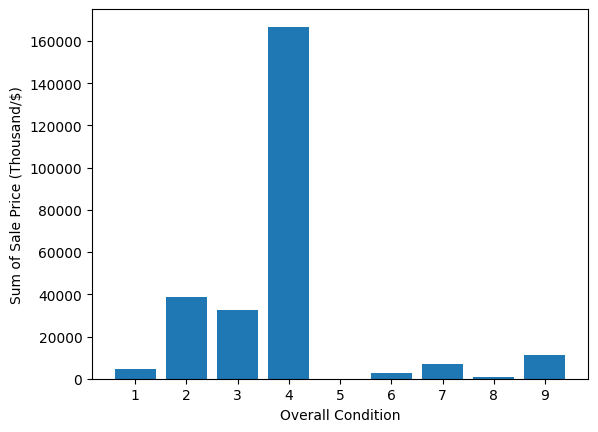

In [19]:
overall_cond = train['OverallCond'].unique()
plt.bar(overall_cond,train.groupby(['OverallCond'])['SalePrice'].sum()/1000)
plt.xticks(overall_cond)
plt.xlabel('Overall Condition')
plt.ylabel('Sum of Sale Price (Thousand/$)')

Text(0, 0.5, 'Sum of Sale Price (Thousand/$)')

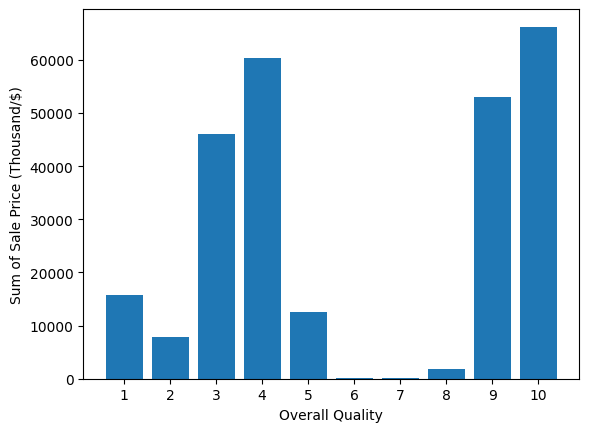

In [20]:
overall_qual = train['OverallQual'].unique()
plt.bar(overall_qual,train.groupby('OverallQual')['SalePrice'].sum()/1000)
plt.xticks(overall_qual)
plt.xlabel('Overall Quality')
plt.ylabel('Sum of Sale Price (Thousand/$)')

Text(0, 0.5, 'Total Sale Price (Thousand/$)')

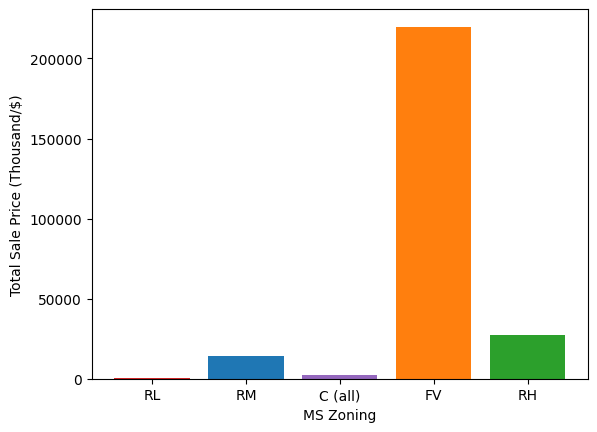

In [21]:
mszoning = train['MSZoning'].unique()
bar_colors = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange', 'tab:green']
plt.bar(mszoning, train.groupby('MSZoning')['SalePrice'].sum()/1000, color = bar_colors)
plt.xticks(mszoning)
plt.xlabel('MS Zoning')
plt.ylabel('Total Sale Price (Thousand/$)')


In [ ]:
correlation_matrix = train.drop(columns = 'Id').corr(numeric_only=True)
corr_pairs = correlation_matrix.unstack()
sorted_paris = corr_pairs.sort_values()
high_corr = sorted_paris[(sorted_paris > 0.5) & (sorted_paris < 1)]
high_corr

2ndFlrSF      BedroomAbvGr    0.502901
BedroomAbvGr  2ndFlrSF        0.502901
SalePrice     YearRemodAdd    0.507101
YearRemodAdd  SalePrice       0.507101
GrLivArea     BedroomAbvGr    0.521270
                                ...   
TotRmsAbvGrd  GrLivArea       0.825489
YearBuilt     GarageYrBlt     0.825667
GarageYrBlt   YearBuilt       0.825667
GarageArea    GarageCars      0.882475
GarageCars    GarageArea      0.882475
Length: 76, dtype: float64

### Outliers Treatment

In [23]:
#Detect and remove outliers in Train Dataset
## LotArea
lower_bound, upper_bound = detect_outliers_iqr(train, 'LotArea')
train = train[(train['LotArea'] > lower_bound) & (train['LotArea'] < upper_bound)]
## GrLivArea
#lower_bound, upper_bound = detect_outliers_iqr(train, 'GrLivArea')
#train = train[(train['GrLivArea'] > lower_bound) & (train['GrLivArea'] < upper_bound)]
#TotRmsAbvGr
train = train[(train['TotRmsAbvGrd'] > 2) & (train['TotRmsAbvGrd'] < 14)]

<Axes: ylabel='LotArea'>

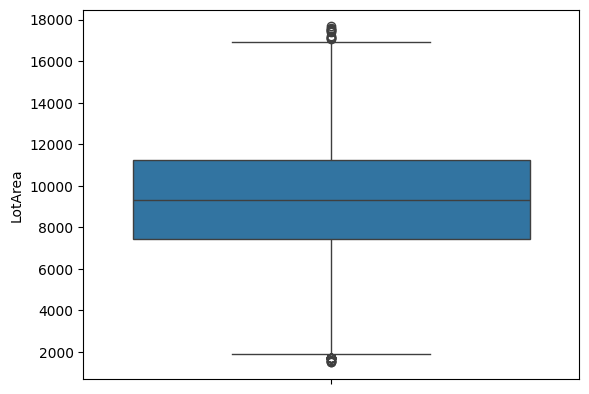

In [24]:
sns.boxplot(train, y = 'LotArea')

### Define the reasons why missing values in each column and the way to replace them
* Missing values in LotFrontage are because of not being recorded
    * Average the LotFrontage with conditions of MSZoning, MSSubclass (reject)
        * it seems like MSZoning and MSSubclass dont have any influence on LotFrontage
    * Average the LotFrontage and fill the missing values with the AVG
* In Alley, there is no clear evidence showing that values are missing because of lack of record 
* If values in MasVnrType are missing because the values dont exist
* If values in MasVnrArea are missing and values in MasVnrType are misisng/none because the values dont exist, 
* Missing values in BsmtQal, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2
having relationship with each other.
    * In particular, index 948, BsmtExposure is missing but other columns of Bsmt are filled
        * it is potential not recorded, therefore, it can be filled with the most frequent value (No)
* 1 missing value in Electrical is due to lack of record
* If values in Fireplace are 0 because the values might not exist
* GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond have relationship with each other, if values in one column are missing, they will also be missing in others
* Missing values in PoolQC, Fence, MiscFeature are because they might not exist

In [25]:
#LotFrontage
LotFrontage_avg_train = train['LotFrontage'].mean()
LotFrontage_avg_test = test['LotFrontage'].mean()
train['LotFrontage'] = train['LotFrontage'].fillna(LotFrontage_avg_train)
test['LotFrontage'] = test['LotFrontage'].fillna(LotFrontage_avg_test)
#BsmtExposure
train.loc[948,'BsmtExposure'] = 'No'
test.loc[27,'BsmtExposure'] = 'No'
test.loc[888,'BsmtExposure'] = 'No'
#TotalBsmtSF
TotalBsmt_avg_train = train['TotalBsmtSF'].mean()
TotalBsmt_avg_test = test['TotalBsmtSF'].mean()
train['TotalBsmtSF'] = train['TotalBsmtSF'].fillna(TotalBsmt_avg_train)
test['TotalBsmtSF'] = test['TotalBsmtSF'].fillna(TotalBsmt_avg_test)

### Handle Category Variables before Regression Modelising
* One-hot coding for category variables having many values but not have any ordinal relationship
* With category variables having many values and they also have ordinal relationship 
(LotShape, LandContour, LandSlope, ExterQual,
ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual, GarageQual, GarageCond,) -> using Label Encoding


In [26]:
def log_transformation(df, features, features_log):
    df[features] = df[features].replace(0, None)
    df[features] = df[features].astype(float)
    df[features_log] = np.log(df[features])
    df.drop(columns = features , axis = 1 , inplace = True )
    return df

In [27]:
features = ['LotArea','GrLivArea','GarageArea', 'BsmtFinSF1', '1stFlrSF', 'YearBuilt']

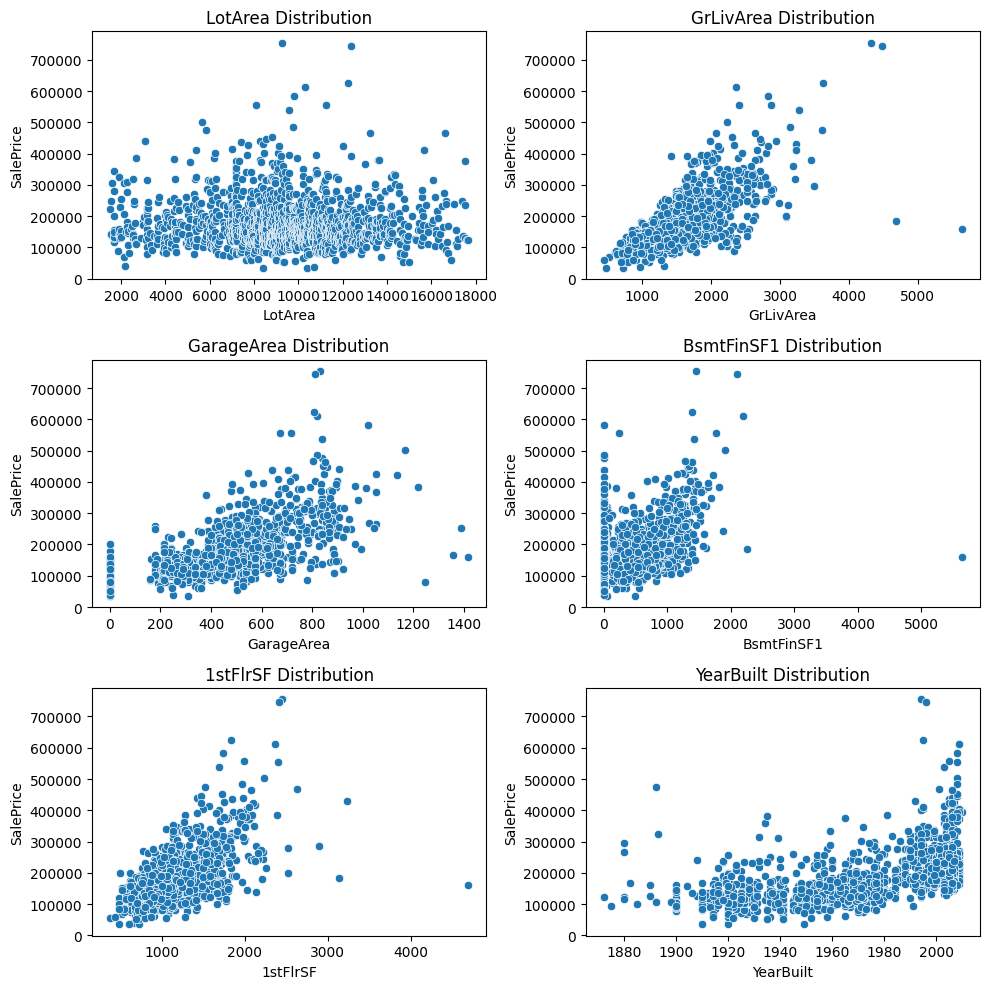

In [28]:
fig, axes = plt.subplots(nrows = 3, ncols = 2,figsize = (10,10))
index = 0
for row in range(len(axes)):
    for col in range(len(axes[row])):
        if index == len(features):
            break
        sns.scatterplot(train, x = features[index], y ='SalePrice', ax = axes[row][col])
        axes[row][col].set_title('{} Distribution'.format(features[index]))
        index +=1
plt.tight_layout()

In [29]:
category_features = ['MSZoning','LandContour','Utilities','LotConfig','Neighborhood','Condition1',
                     'Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType'
                     ,'Foundation','Heating','Electrical','Functional','GarageType','PavedDrive','PavedDrive',
                     'Fence','MiscFeature','SaleType','SaleCondition']
encoding_features = ['Street', 'Alley','CentralAir']
ordinal_features_15 = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual',
                       'GarageQual','GarageCond']
ordinal_features_05 = ['BsmtFinType1','BsmtFinType2',]
ordinal_features_13 = ['LandSlope']
ordinal_feature_02 =['GarageFinish']
ordinal_features_03 = ['LotShape','BsmtExposure',]

In [30]:
#Encoding Lable
#encoder = LabelEncoder()
#for feature in encoding_features:
#    train[feature] = encoder.fit_transform(train[feature])
#    test[feature] = encoder.transform(test[feature])

In [31]:
convert_scale_15 = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
convert_scale_05 = {'Unf': 0, 'LwQ': 1, 'Rec': 2, 'BLQ': 3, 'ALQ': 4, 'GLQ': 5}
convert_scale_LandSlope = {'Gtl': 1, 'Mod': 2, 'Sev': 3}
convert_scale_LotShape = {'Reg': 0, 'IR1': 1,'IR2': 2,'IR3': 3}
convert_scale_Finish = {'Fin':3,'RFn':2,'Unf':1}

In [32]:
train[ordinal_features_15] = train[ordinal_features_15].replace(convert_scale_15)
train[ordinal_features_05] = train[ordinal_features_05].replace(convert_scale_05)
train['GarageFinish'] = train['GarageFinish'].replace(convert_scale_Finish)
train['LotShape'] = train['LotShape'].replace(convert_scale_LotShape)

C:\Users\Rice\AppData\Local\Temp\ipykernel_8164\2940019638.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[ordinal_features_15] = train[ordinal_features_15].replace(convert_scale_15)
C:\Users\Rice\AppData\Local\Temp\ipykernel_8164\2940019638.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[ordinal_features_05] = train[ordinal_features_05].replace(convert_scale_05)
C:\Users\Rice\AppData\Local\Temp\ipykernel_8164\2940019638.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in

In [33]:
test[ordinal_features_15] = test[ordinal_features_15].replace(convert_scale_15)
test[ordinal_features_05] = test[ordinal_features_05].replace(convert_scale_05)
test['GarageFinish'] = test['GarageFinish'].replace(convert_scale_Finish)
test['LotShape'] = test['LotShape'].replace(convert_scale_LotShape)

C:\Users\Rice\AppData\Local\Temp\ipykernel_8164\2693908129.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[ordinal_features_15] = test[ordinal_features_15].replace(convert_scale_15)
C:\Users\Rice\AppData\Local\Temp\ipykernel_8164\2693908129.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[ordinal_features_05] = test[ordinal_features_05].replace(convert_scale_05)
C:\Users\Rice\AppData\Local\Temp\ipykernel_8164\2693908129.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a f

In [34]:
train = pd.get_dummies(train, columns=['Street','LandSlope'], drop_first=True)
test = pd.get_dummies(test, columns = ['Street','LandSlope'], drop_first=True)

In [35]:
features = ['GrLivArea','LotArea','1stFlrSF','TotalBsmtSF']

#### Choosing variables to forecast

In [36]:
indie_vars = features + ordinal_features_15+ \
['TotRmsAbvGrd','FullBath'] + ['Street_Pave','LandSlope_Mod','LandSlope_Sev']\
+ ['MSSubClass','YearBuilt']

In [37]:
X = train[indie_vars]
y = train['SalePrice']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size= 0.2, random_state=0)
house_model = RandomForestRegressor(random_state=0)
house_model.fit(X,y)
house_predictions = house_model.predict(test_X)
print('Training Score: {}'.format(house_model.score(train_X, train_y)))
print('Testing Score: {}'.format(house_model.score(test_X, test_y)))

Training Score: 0.9737210989324903
Testing Score: 0.9766882592430919


In [38]:
print('The predictions of Price: {}'.format(house_predictions[0:5]))
print('RMSE: {}'.format(root_mean_squared_error(test_y, house_predictions)))
print('MAE: {}'.format(mean_absolute_error(test_y, house_predictions)))
print('MSE: {}'.format(mean_squared_error(test_y,house_predictions)))

The predictions of Price: [112868.83 164938.   111786.42 260614.78 205133.  ]
RMSE: 11518.640056552407
MAE: 7656.52345323741
MSE: 132679068.75241366


In [39]:
test_X = test[indie_vars]
test_ID = test['Id']
output1 = pd.DataFrame({'Id': test_ID, 'SalePrice': house_model.predict(test_X)})
#output1.to_csv('submission_.csv', index = False)
print(output1.head())
print('\nMinimum Sale Price',output1['SalePrice'].min())
print('\nMaximum Sale Price', output1['SalePrice'].max())

     Id  SalePrice
0  1461   120749.0
1  1462   151638.5
2  1463   177113.0
3  1464   183550.0
4  1465   192243.8

Minimum Sale Price 69045.88

Maximum Sale Price 551528.82


#### Log-Linear Regression

In [40]:
log_train = train.copy()
log_test = test.copy()
features_train = ['LotArea','LotFrontage','1stFlrSF','GrLivArea','SalePrice']
features_log_train = []
for col in features_train:
    features_log_train.append(col +'_log')

In [41]:
features_test =['LotArea','LotFrontage','1stFlrSF','GrLivArea',]
features_log_test = []
for col in features_test:
    features_log_test.append(col +'_log')

In [42]:
log_transformation(log_train,features_train, features_log_train)
log_transformation(log_test,features_test, features_log_test)

,Id,MSSubClass,MSZoning,LotShape,LandContour,Utilities,LotConfig,Neighborhood,Condition1,Condition2,...,YrSold,SaleType,SaleCondition,Street_Pave,LandSlope_Mod,LandSlope_Sev,LotArea_log,LotFrontage_log,1stFlrSF_log,GrLivArea_log
0,1461,20,RH,0,Lvl,AllPub,Inside,NAmes,Feedr,Norm,...,2010,WD,Normal,True,False,False,9.360655,4.382027,6.797940,6.797940
1,1462,20,RL,1,Lvl,AllPub,Corner,NAmes,Norm,Norm,...,2010,WD,Normal,True,False,False,9.565704,4.394449,7.192182,7.192182
2,1463,60,RL,1,Lvl,AllPub,Inside,Gilbert,Norm,Norm,...,2010,WD,Normal,True,False,False,9.534595,4.304065,6.833032,7.395722
3,1464,60,RL,1,Lvl,AllPub,Inside,Gilbert,Norm,Norm,...,2010,WD,Normal,True,False,False,9.208138,4.356709,6.830874,7.380256
4,1465,120,RL,1,HLS,AllPub,Inside,StoneBr,Norm,Norm,...,2010,WD,Normal,True,False,False,8.518193,3.761200,7.154615,7.154615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,0,Lvl,AllPub,Inside,MeadowV,Norm,Norm,...,2006,WD,Normal,True,False,False,7.568379,3.044522,6.302619,6.995766
1455,2916,160,RM,0,Lvl,AllPub,Inside,MeadowV,Norm,Norm,...,2006,WD,Abnorml,True,False,False,7.546446,3.044522,6.302619,6.995766
1456,2917,20,RL,0,Lvl,AllPub,Inside,Mitchel,Norm,Norm,...,2006,WD,Abnorml,True,False,False,9.903488,5.075174,7.109879,7.109879
1457,2918,85,RL,0,Lvl,AllPub,Inside,Mitchel,Norm,Norm,...,2006,WD,Normal,True,False,False,9.253496,4.127134,6.877296,6.877296


In [43]:
features = ['GrLivArea_log','LotArea_log','1stFlrSF_log']

In [44]:
indie_vars = features + ordinal_features_15+ ordinal_features_05+ \
['TotRmsAbvGrd','FullBath'] +['Street_Pave','LandSlope_Mod','LandSlope_Sev'] +\
['MSSubClass','YearBuilt'] 

In [45]:
X = log_train[indie_vars]
y = log_train['SalePrice_log']
train_X, test_X, train_y, test_y = train_test_split(X,y, test_size= 0.2,random_state = 0)

In [46]:
house_model = RandomForestRegressor(random_state=0)
house_model.fit(X,y)
house_predictions = house_model.predict(test_X)
print('Training Score: {}'.format(house_model.score(train_X, train_y)))
print('Testing Score: {}'.format(house_model.score(test_X, test_y)))

Training Score: 0.9765852196161717
Testing Score: 0.9754560849665531


In [47]:
print('The predictions of Price: {}'.format(house_predictions[0:5]))
print('RMSE: {}'.format(root_mean_squared_error(test_y, house_predictions)))
print('MAE: {}'.format(mean_absolute_error(test_y, house_predictions)))
print('MSE: {}'.format(mean_squared_error(test_y,house_predictions)))

The predictions of Price: [11.61562871 12.01332851 11.59823602 12.47272455 12.23517912]
RMSE: 0.06202542799613683
MAE: 0.042462457662573776
MSE: 0.003847153718103954


In [48]:
test_X = log_test[indie_vars]
test_ID = log_test['Id']
output2 = pd.DataFrame({'Id': test_ID, 'SalePrice': np.exp(house_model.predict(test_X))})
#output1.to_csv('submission_.csv', index = False)
print(output2.head())
print('\nMinimum Sale Price',(output2['SalePrice'].min()))
print('\nMaximum Sale Price', (output2['SalePrice'].max()))

     Id      SalePrice
0  1461  120708.834968
1  1462  151590.279919
2  1463  179480.462570
3  1464  187691.520539
4  1465  186061.265731

Minimum Sale Price 59906.279837607

Maximum Sale Price 526299.7584999828
